# Correlation & Mean-Reversion Spread Study

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
import yfinance as yf
from dataProvider import get_df

pd.set_option("display.width", 140)
%matplotlib inline

In [3]:
MODEL_WINDOW = 60
ZSCORE_WINDOW = 41
ENTRY_ZSCORE = 4.0
FLAT_ZSCORE = 0.0
STOP_ZSCORE = 4.7

CORR_WINDOW = 60*24

## 2. Data loading

In [4]:
df = get_df(before='2027-01-01')

df

,A,B
Datetime,,
2020-01-01 00:00:00,1.32463,1.12139
2020-01-01 00:15:00,1.32463,1.12139
2020-01-01 00:30:00,1.32463,1.12139
2020-01-01 00:45:00,1.32463,1.12139
2020-01-01 01:00:00,1.32463,1.12139
...,...,...
2026-08-17 22:45:00,1.35436,1.15785
2026-08-17 23:00:00,1.35454,1.15800
2026-08-17 23:15:00,1.35474,1.15811


In [5]:
# TICKER_A = "EURUSD=X"
# TICKER_B = "GBPUSD=X"
# TIMEFRAME = "15m"

# a_df = yf.download(TICKER_A, period="max", interval=TIMEFRAME)
# b_df = yf.download(TICKER_B, period="max", interval=TIMEFRAME)

# a_df.columns.names = [None, None]
# a_df.columns = a_df.columns.get_level_values(0)
# a_df = a_df.drop(columns=["Volume"])

# b_df.columns.names = [None, None]
# b_df.columns = b_df.columns.get_level_values(0)
# b_df = b_df.drop(columns=["Volume"])

# a_df

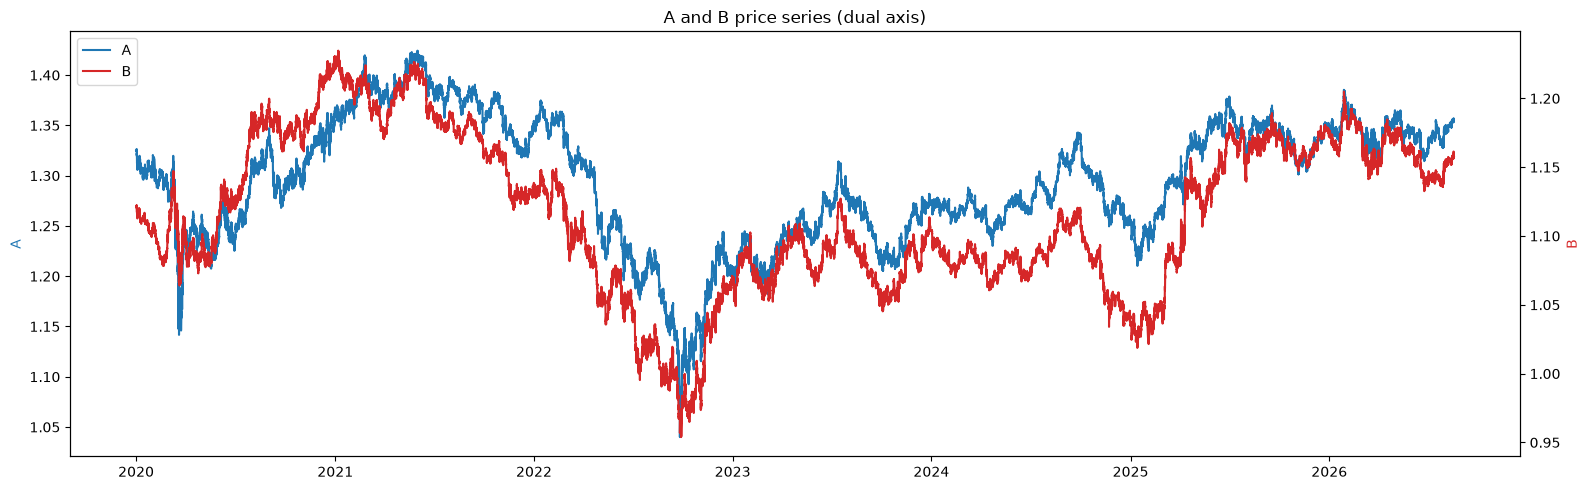

In [6]:
fig, ax_a = plt.subplots(figsize=(16, 5))
ax_b = ax_a.twinx()

ax_a.plot(df.index, df["A"], color="#1f77b4", label="A")
ax_b.plot(df.index, df["B"], color="#d62728", label="B")

ax_a.set_ylabel("A", color="#1f77b4")
ax_b.set_ylabel("B", color="#d62728")

ax_a.set_title("A and B price series (dual axis)")

lines1, labels1 = ax_a.get_legend_handles_labels()
lines2, labels2 = ax_b.get_legend_handles_labels()

ax_a.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Correlation & Contegration study

Full-sample return correlation (A vs B): 0.7027
Rolling 1440-bar correlation: mean=0.7170, min=0.2578, max=0.9119


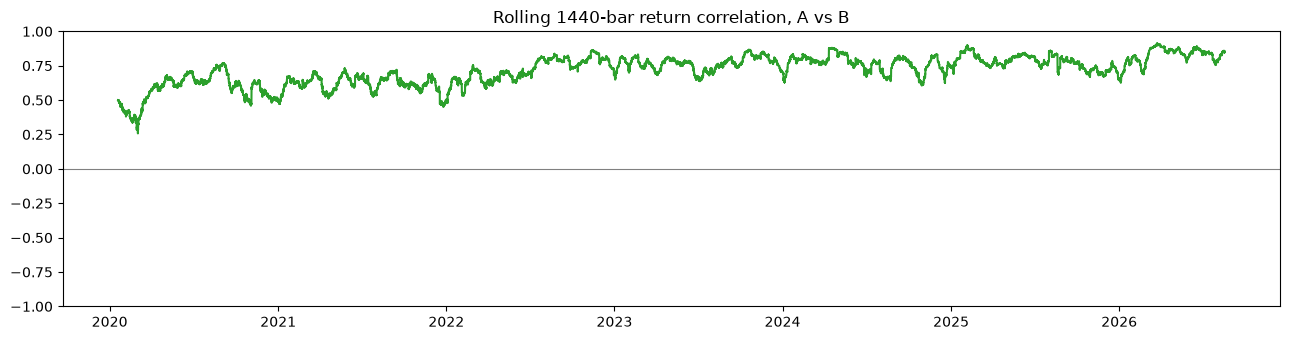

In [7]:
returns_df = df.pct_change().dropna()

full_corr = returns_df["A"].corr(returns_df["B"])
rolling_corr = returns_df["A"].rolling(CORR_WINDOW).corr(returns_df["B"])

print(f"Full-sample return correlation (A vs B): {full_corr:.4f}")
print(f"Rolling {CORR_WINDOW}-bar correlation: mean={rolling_corr.mean():.4f}, "f"min={rolling_corr.min():.4f}, max={rolling_corr.max():.4f}")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(rolling_corr.index, rolling_corr.values, color="#2ca02c")
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylim(-1, 1)
ax.set_title(f"Rolling {CORR_WINDOW}-bar return correlation, A vs B")

plt.tight_layout()
plt.show()

## 4. Hedge-ratio-adjusted spread

- estimate a rolling hedge ratio (beta) via OLS: `A_t = alpha + beta * B_t + spread_t`

- and treat `spread_t` as the mean-reverting quantity. Beta is refit on a rolling window so it adapts to slow drift in the relationship (e.g. tech's growing weight in the S&P 500 pulls ES and NQ closer over time).

In [8]:
def pair_spread_mean_reversion_model(window=MODEL_WINDOW):
    Y = df["A"]

    X = sm.add_constant(df["B"])
    rolling_model = RollingOLS(Y, X, window=window)
    fit = rolling_model.fit()

    _beta = fit.params["B"]
    _alpha = fit.params["const"]
    _spread = (df["A"] - (_alpha + _beta * df["B"])).dropna()
    _beta = _beta.reindex(_spread.index)

    return _alpha, _beta, _spread

alpha, beta, spread = pair_spread_mean_reversion_model()

### Plot spread

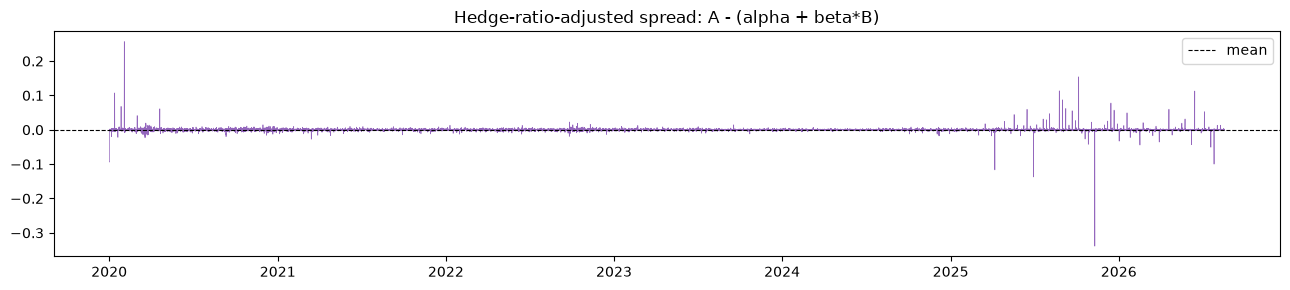

In [9]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(spread.index, spread.values, color="#9467bd", lw=0.5)
ax.axhline(spread.mean(), color="black", lw=0.8, ls="--", label="mean")
ax.set_title("Hedge-ratio-adjusted spread: A - (alpha + beta*B)")

ax.legend()
plt.tight_layout()
plt.show()

## 5. Stationarity test (ADF)

A real mean-reversion strategy needs the spread to be statistically stationary — not just "look like" it reverts on a chart.

In [10]:
def ADF_test_model(_spread):
    result = adfuller(_spread.dropna(), autolag="AIC")
    stat, pvalue, lags, nobs, crit_values, _ = result

    print(f"ADF statistic: {stat:.4f}")
    print(f"p-value:       {pvalue:.4f}")
    print("Critical values:", {k: round(v, 3) for k, v in crit_values.items()})

    if pvalue < 0.05:
        print("=> Spread appears stationary (mean-reverting) at 5% significance.")
        return True
    else:
        print("=> Spread does NOT reject the unit-root null -- mean reversion is not "
            "statistically supported on this sample. Don't trade a non-stationary spread.")
        return False

_ = ADF_test_model(spread.dropna().tail(10000))

ADF statistic: -12.7560
p-value:       0.0000
Critical values: {'1%': np.float64(-3.431), '5%': np.float64(-2.862), '10%': np.float64(-2.567)}
=> Spread appears stationary (mean-reverting) at 5% significance.


---

## 6. Mean-reversion strategy

Rules (classic pairs-trading / stat-arb):
- `z` = rolling z-score of the spread
- `z > +ENTRY_Z` → spread is rich: **short** the spread (short ES, long NQ×beta)
- `z < -ENTRY_Z` → spread is cheap: **long** the spread (long ES, short NQ×beta)
- `|z| < EXIT_Z` → flatten (reverted to mean)
- `|z| > STOP_Z` → hard stop (relationship may have broken down)

## 7. Backtest stats

In [11]:
def pair_spread_mean_reversion(
    z_window=ZSCORE_WINDOW,
    z_entry=ENTRY_ZSCORE,
    z_flat=FLAT_ZSCORE,
    z_stop=STOP_ZSCORE
):
    # --- Z-score of the spread ---
    spread_mean = spread.rolling(z_window).mean()
    spread_std = spread.rolling(z_window).std()
    zscore = (spread - spread_mean) / spread_std

    # --- State machine: -1 = short spread, 0 = flat, 1 = long spread ---
    state = np.zeros(len(zscore), dtype=int)
    current = 0

    z_vals = zscore.to_numpy()
    for i, z in enumerate(z_vals):
        if current == 0:
            if z < -z_entry: current = 1
            elif z > z_entry: current = -1
        elif abs(z) < z_flat: current = 0
        elif abs(z) > z_stop: current = 0
        state[i] = current

    state = pd.Series(state, index=zscore.index)

    # --- Positions (lagged by 1 to avoid lookahead) ---
    position_A = state.shift(1).fillna(0)
    position_B = (-state * beta).shift(1).fillna(0)

    # --- Returns ---
    ret_A = returns_df["A"]
    ret_B = returns_df["B"]

    strategy_returns = position_A * ret_A + position_B * ret_B
    equity = (1 + strategy_returns).cumprod()

    return strategy_returns, equity

In [12]:
_, equity = pair_spread_mean_reversion()

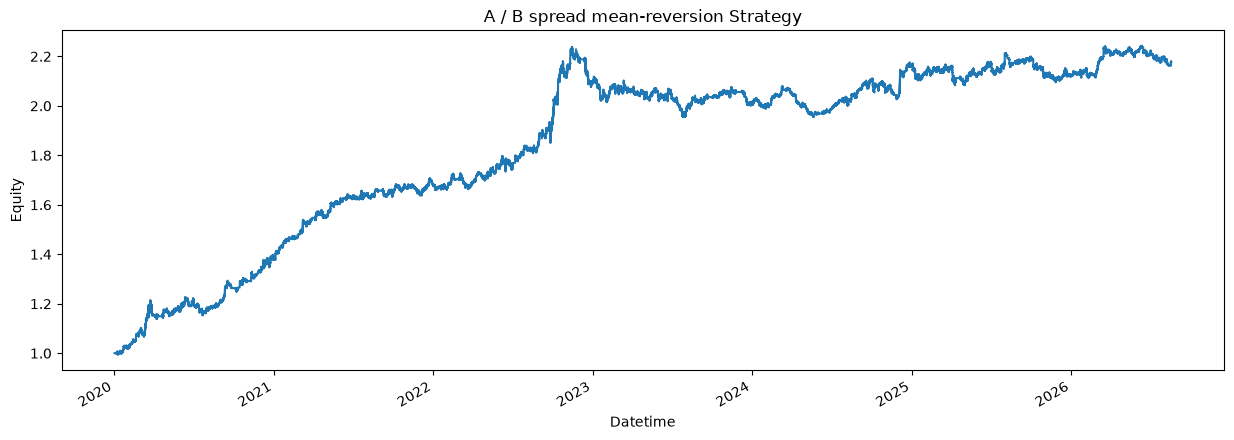

In [13]:
equity.plot(figsize=(15, 5))
plt.ylabel("Equity")
plt.title("A / B spread mean-reversion Strategy")
plt.show()

In [14]:
def compute_metrics(equity: pd.Series, trade_epsilon: float = 1e-12) -> dict:
    equity = equity.dropna().astype(float)
    equity = equity.sort_index()

    # --- Return ---
    total_return_pct = (equity.iloc[-1] / equity.iloc[0] - 1)

    # --- Max Drawdown % ---
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    max_drawdown_pct = drawdown.min() * 100  # negative number

    # --- Sharp ratio ---
    returns = equity.pct_change().dropna()
    vol = returns.std()

    # --- Trades: inferred from nonzero equity changes ---
    equity_diff = equity.diff().dropna()
    trade_pnls = equity_diff[equity_diff.abs() > trade_epsilon]

    num_trades = len(trade_pnls)
    wins = trade_pnls[trade_pnls > 0]
    losses = trade_pnls[trade_pnls < 0]

    win_rate_pct = (len(wins) / num_trades * 100) if num_trades > 0 else np.nan
    max_win = wins.max() if len(wins) > 0 else np.nan
    max_loss = losses.min() if len(losses) > 0 else np.nan

    return {
        "Return %": round(total_return_pct * 100, 4),
        "Max Drawdown %": round(max_drawdown_pct, 4),
        "Sharp ratio": round(total_return_pct/vol, 4),
        "Win Rate %": round(win_rate_pct, 2) if not np.isnan(win_rate_pct) else np.nan,
        "Number of trades": num_trades,
        "Max win": round(max_win, 6) if not np.isnan(max_win) else np.nan,
        "Max loss": round(max_loss, 6) if not np.isnan(max_loss) else np.nan,
    }

def print_metrics(_result): 
    for k, v in _result.items(): print(f"{k}: {v}")


result = compute_metrics(equity)

print_metrics(result)

Return %: 117.8738
Max Drawdown %: -12.6661
Sharp ratio: 2432.5844
Win Rate %: 50.02
Number of trades: 151050
Max win: 0.088618
Max loss: -0.040047


In [15]:
# from itertools import product

# z_windows = []
# z_entries = []
# z_flats = []
# z_stops = []

# metrics = {}

# for zw, ze, zf, zs  in product(z_windows, z_entries, z_flats, z_stops):
#     _equity = pair_spread_mean_reversion(
#         zscore={
#             "window": zw,
#             "entry": ze,
#             "flat": zf,
#             "stop": zs
#         },
#     )
#     metrics[(zw, ze, zf, zs)] = compute_metrics(_equity)

# best_metrics = sorted(
#     metrics.items(),
#     key=lambda x: x[1]["Max Balance DD %"]
# )[:3]

# # only three best ones
# for (zw, ze, zf, zs), _metrics in best_metrics:
#     print(f"Rolling window: {zw}, z entry: {ze}, z flat: {zf}, z_stop: {zs}")
#     print_metrics(_metrics)
#     print("\n\n--------------------------------------------------\n\n")

# print("Done!")